In [2]:
!pip install -q flaml[automl] pandas numpy matplotlib seaborn scikit-learn shap lightgbm xgboost

In [3]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import time
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, brier_score_loss,
    ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve  # not in sklearn.metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from flaml import AutoML  # pycaret dropped python 3.12 support; flaml works fine
import shap
shap.initjs()

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")


In [7]:
import os
import pandas as pd

base = "/workspaces/Data-hw-4/Archive"  # folder that contains the CSVs

orders      = pd.read_csv(os.path.join(base, "olist_orders_dataset.csv"))
order_items = pd.read_csv(os.path.join(base, "olist_order_items_dataset.csv"))
payments    = pd.read_csv(os.path.join(base, "olist_order_payments_dataset.csv"))
reviews     = pd.read_csv(os.path.join(base, "olist_order_reviews_dataset.csv"))
customers   = pd.read_csv(os.path.join(base, "olist_customers_dataset.csv"))
products    = pd.read_csv(os.path.join(base, "olist_products_dataset.csv"))
sellers     = pd.read_csv(os.path.join(base, "olist_sellers_dataset.csv"))

FileNotFoundError: [Errno 2] No such file or directory: '/workspaces/Data-hw-4/Archive/olist_orders_dataset.csv'

In [7]:
base = r"C:\Users\gdougherty\Documents\GitHub\DATA6545_HW4\hw4-mlops-\requirements.txt\Archives"

orders      = pd.read_csv(os.path.join(base, "olist_orders_dataset.csv"))
order_items = pd.read_csv(os.path.join(base, "olist_order_items_dataset.csv"))
payments    = pd.read_csv(os.path.join(base, "olist_order_payments_dataset.csv"))
reviews     = pd.read_csv(os.path.join(base, "olist_order_reviews_dataset.csv"))
customers   = pd.read_csv(os.path.join(base, "olist_customers_dataset.csv"))
products    = pd.read_csv(os.path.join(base, "olist_products_dataset.csv"))
sellers     = pd.read_csv(os.path.join(base, "olist_sellers_dataset.csv"))


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\gdougherty\\Documents\\GitHub\\DATA6545_HW4\\hw4-mlops-\\requirements.txt\\Archives/olist_orders_dataset.csv'

In [ ]:
# 1 = positive review (4–5 stars), 0 = negative review (1–3 stars)
reviews_simple = reviews[["order_id", "review_score"]].drop_duplicates("order_id")
reviews_simple["is_positive_review"] = (reviews_simple["review_score"] >= 4).astype(int)

In [ ]:
# keep only delivered orders with full date fields
for col in ["order_purchase_timestamp", "order_delivered_customer_date",
            "order_estimated_delivery_date"]:
    orders[col] = pd.to_datetime(orders[col])

orders_simple = orders[
    (orders["order_status"] == "delivered") &
    orders["order_delivered_customer_date"].notna() &
    orders["order_estimated_delivery_date"].notna()
].copy()

orders_with_target = pd.merge(orders_simple, reviews_simple, on="order_id", how="inner")
print("Orders with reviews:", orders_with_target.shape)

# --- Engineered Feature 1: delivery_days ---
# Number of days from purchase to actual delivery
orders_with_target["delivery_days"] = (
    orders_with_target["order_delivered_customer_date"] -
    orders_with_target["order_purchase_timestamp"]
).dt.days

# --- Engineered Feature 2: delivery_vs_estimated ---
# How many days early (negative) or late (positive) vs. the promised date
orders_with_target["delivery_vs_estimated"] = (
    orders_with_target["order_delivered_customer_date"] -
    orders_with_target["order_estimated_delivery_date"]
).dt.days

# --- Engineered Feature 3: order_purchase_dow ---
# Day of week (0=Monday, 6=Sunday)
orders_with_target["order_purchase_dow"] = (
    orders_with_target["order_purchase_timestamp"].dt.dayofweek
)

# --- Item-level aggregations ---
items_group = order_items.groupby("order_id")
order_items_agg = pd.DataFrame()
order_items_agg["n_items"]       = items_group["order_item_id"].count()
order_items_agg["n_sellers"]     = items_group["seller_id"].nunique()
order_items_agg["total_price"]   = items_group["price"].sum()
order_items_agg["total_freight"] = items_group["freight_value"].sum()
order_items_agg["avg_price"]     = items_group["price"].mean()
order_items_agg = order_items_agg.reset_index()

# --- Product category: first category per order ---
items_with_products = pd.merge(
    order_items[["order_id", "product_id"]],
    products[["product_id", "product_category_name"]],
    on="product_id", how="left"
)
prod_agg = (items_with_products
            .groupby("order_id")["product_category_name"]
            .first()
            .reset_index()
            .rename(columns={"product_category_name": "product_category"}))

# --- Seller state: first seller per order ---
items_with_sellers = pd.merge(
    order_items[["order_id", "seller_id"]],
    sellers[["seller_id", "seller_state"]],
    on="seller_id", how="left"
)
seller_agg = (items_with_sellers
              .groupby("order_id")["seller_state"]
              .first()
              .reset_index())

# --- Payment aggregations ---
payments_group = payments.groupby("order_id")
payments_agg = pd.DataFrame()
payments_agg["payment_type"]         = payments_group["payment_type"].first()
payments_agg["payment_installments"] = payments_group["payment_installments"].max()
payments_agg["payment_value"]        = payments_group["payment_value"].sum()
payments_agg = payments_agg.reset_index()

# --- Merge everything into one flat DataFrame ---
data = orders_with_target.copy()
data = pd.merge(data, order_items_agg, on="order_id", how="left")
data = pd.merge(data, prod_agg,        on="order_id", how="left")
data = pd.merge(data, seller_agg,      on="order_id", how="left")
data = pd.merge(data, payments_agg,    on="order_id", how="left")
print("Final dataset shape:", data.shape)
data.head()

Orders with reviews: (95824, 10)
Final dataset shape: (95824, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,is_positive_review,...,n_items,n_sellers,total_price,total_freight,avg_price,product_category,seller_state,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,4,1,...,1,1,29.99,8.72,29.99,utilidades_domesticas,SP,credit_card,1.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,4,1,...,1,1,118.70,22.76,118.70,perfumaria,SP,boleto,1.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,5,1,...,1,1,159.90,19.22,159.90,automotivo,SP,credit_card,3.0,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,5,1,...,1,1,45.00,27.20,45.00,pet_shop,MG,credit_card,1.0,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,5,1,...,1,1,19.90,8.72,19.90,papelaria,SP,credit_card,1.0,28.62


In [ ]:
feature_cols = [
    "delivery_days",
    "delivery_vs_estimated",
    "order_purchase_dow",    # engineered
    "total_price",
    "total_freight",
    "n_items",
    "n_sellers",
    "avg_price",
    "payment_value",
    "payment_installments",
    "product_category",      # categorical
    "seller_state",          # categorical
    "payment_type",          # categorical
]
target_col = "is_positive_review"

# drop rows with any missing values
model_data = data[feature_cols + [target_col]].dropna()
X = model_data[feature_cols]
y = model_data[target_col]

print(f"Modeling dataset: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Class distribution:\n{y.value_counts(normalize=True).round(3)}")

# 80/20 split — SAME random_state=42 as HW2 so results are directly comparable
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train size:", X_train.shape)
print("Test  size:", X_test.shape)


NameError: name 'data' is not defined

In [ ]:
# which columns are numeric vs. categorical?
numeric_features     = [
    "delivery_days", "delivery_vs_estimated", "order_purchase_dow",
    "total_price", "total_freight", "n_items", "n_sellers",
    "avg_price", "payment_value", "payment_installments",
]
categorical_features = ["product_category", "seller_state", "payment_type"]

# numeric pipeline: scale so all features have mean=0 and std=1
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])
# categorical pipeline: one-hot encode
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
# combine both transformers
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer,     numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# preprocess once — FLAML takes arrays, not DataFrames with mixed types
# we fit on train and transform both (same leakage-free approach as HW2)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)
print(f"Preprocessed shape: {X_train_proc.shape}")


Preprocessed shape: (75599, 109)


In [ ]:
hw2_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100, max_depth=10,
        min_samples_split=5, max_features=0.3,
        random_state=42, n_jobs=-1,
    )),
])

print("Training HW2 baseline...")
hw2_pipeline.fit(X_train, y_train)
y_pred_hw2  = hw2_pipeline.predict(X_test)
y_proba_hw2 = hw2_pipeline.predict_proba(X_test)[:, 1]

print("\n=== HW2 Tuned Random Forest — Test Set ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_hw2):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_hw2):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_hw2):.4f}")
print(f"F1        : {f1_score(y_test, y_pred_hw2):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_hw2):.4f}")


Training HW2 baseline...

=== HW2 Tuned Random Forest — Test Set ===
Accuracy  : 0.8267
Precision : 0.8306
Recall    : 0.9804
F1        : 0.8993
ROC-AUC   : 0.7123


##**Experiment A: Constrained (Same HW2 Features, 10-min budget)**

In [ ]:
print("Running Experiment A (10-min budget, HW2 features)...")
start_A  = time.time()
automl_A = AutoML()
automl_A.fit(
    X_train_proc, y_train,
    task        = "classification",
    time_budget = 600,          # 10 minutes in seconds
    metric      = "roc_auc",
    n_splits    = 5,            # 5-fold CV internally
    seed        = 42,
    verbose     = 1,
)
elapsed_A = time.time() - start_A
print(f"\nExperiment A done in {elapsed_A/60:.1f} min")
print(f"Best model     : {automl_A.best_estimator}")
print(f"Best CV ROC-AUC: {1 - automl_A.best_loss:.4f}")


Running Experiment A (10-min budget, HW2 features)...

Experiment A done in 10.0 min
Best model     : xgboost
Best CV ROC-AUC: 0.7236


In [ ]:
y_pred_A  = automl_A.predict(X_test_proc)
y_proba_A = automl_A.predict_proba(X_test_proc)[:, 1]

print("\n=== Experiment A — Test Set ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_A):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_A):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_A):.4f}")
print(f"F1        : {f1_score(y_test, y_pred_A):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_A):.4f}")

# show all model types FLAML tried
print("\n=== Experiment A — Models Explored ===")
for estimator, config in automl_A.best_config_per_estimator.items():
    print(f"  {estimator}")


=== Experiment A — Test Set ===
Accuracy  : 0.8277
Precision : 0.8322
Recall    : 0.9793
F1        : 0.8998
ROC-AUC   : 0.7128

=== Experiment A — Models Explored ===
  lgbm
  rf
  xgboost
  extra_tree
  xgb_limitdepth
  sgd
  lrl1


##**Experiment B: Unconstrained (Extended Features, 20-min budget)**

In [ ]:
# add extra features AutoML can work with freely
data["freight_ratio"]        = data["total_freight"] / data["total_price"].replace(0, np.nan)
data["order_purchase_hour"]  = pd.to_datetime(data["order_purchase_timestamp"]).dt.hour
data["order_purchase_month"] = pd.to_datetime(data["order_purchase_timestamp"]).dt.month

extended_cols = feature_cols + ["freight_ratio", "order_purchase_hour", "order_purchase_month"]
model_data_ext = data[extended_cols + [target_col]].dropna()
X_ext = model_data_ext[extended_cols]
y_ext = model_data_ext[target_col]

X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_ext, y_ext, test_size=0.2, stratify=y_ext, random_state=42
)
print("Extended train:", X_train_ext.shape, "| test:", X_test_ext.shape)

# build extended preprocessor (same logic, more numeric features)
ext_numeric = numeric_features + ["freight_ratio", "order_purchase_hour", "order_purchase_month"]
ext_preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[("scaler", StandardScaler())]),                          ext_numeric),
    ("cat", Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore",
                                                      sparse_output=False))]),       categorical_features),
])
X_train_ext_proc = ext_preprocessor.fit_transform(X_train_ext)
X_test_ext_proc  = ext_preprocessor.transform(X_test_ext)
print(f"Extended preprocessed shape: {X_train_ext_proc.shape}")


Extended train: (75599, 16) | test: (18900, 16)
Extended preprocessed shape: (75599, 112)


In [ ]:
print("Running Experiment B (20-min budget, extended features)...")
start_B  = time.time()
automl_B = AutoML()
automl_B.fit(
    X_train_ext_proc, y_train_ext,
    task        = "classification",
    time_budget = 1200,         # 20 minutes in seconds
    metric      = "roc_auc",
    n_splits    = 5,
    seed        = 42,
    verbose     = 1,
)
elapsed_B = time.time() - start_B
print(f"\nExperiment B done in {elapsed_B/60:.1f} min")
print(f"Best model     : {automl_B.best_estimator}")
print(f"Best CV ROC-AUC: {1 - automl_B.best_loss:.4f}")


Running Experiment B (20-min budget, extended features)...

Experiment B done in 20.2 min
Best model     : xgboost
Best CV ROC-AUC: 0.7236


In [ ]:
y_pred_B  = automl_B.predict(X_test_ext_proc)
y_proba_B = automl_B.predict_proba(X_test_ext_proc)[:, 1]

print("\n=== Experiment B — Test Set ===")
print(f"Accuracy  : {accuracy_score(y_test_ext, y_pred_B):.4f}")
print(f"Precision : {precision_score(y_test_ext, y_pred_B):.4f}")
print(f"Recall    : {recall_score(y_test_ext, y_pred_B):.4f}")
print(f"F1        : {f1_score(y_test_ext, y_pred_B):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test_ext, y_proba_B):.4f}")

print("\n=== Experiment B — Models Explored ===")
for estimator, config in automl_B.best_config_per_estimator.items():
    print(f"  {estimator}")



=== Experiment B — Test Set ===
Accuracy  : 0.8277
Precision : 0.8327
Recall    : 0.9784
F1        : 0.8997
ROC-AUC   : 0.7157

=== Experiment B — Models Explored ===
  lgbm
  rf
  xgboost
  extra_tree
  xgb_limitdepth
  sgd
  lrl1


In [ ]:
# ── Exp B: Feature Importance from AutoML ────────────────────────────────────
print("=== Experiment B — Top Feature Importances (AutoML XGBoost) ===")
import pandas as pd

# Get feature importances from the best AutoML B model
aml_b_model = automl_B.model.estimator
fi = aml_b_model.feature_importances_

# Build feature name list (matches ext_preprocessor column order)
ext_num_names = ext_numeric   # list of numeric feature names
# Get OHE category names
ohe_cats = ext_preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features).tolist()
all_feature_names = ext_num_names + ohe_cats

fi_df = pd.DataFrame({"Feature": all_feature_names, "Importance": fi})
fi_df = fi_df.sort_values("Importance", ascending=False).head(10).reset_index(drop=True)
fi_df.index += 1
print(fi_df.to_string())

=== Experiment B — Top Feature Importances (AutoML XGBoost) ===
                                Feature  Importance
1                               n_items    0.048184
2                             n_sellers    0.040685
3                 delivery_vs_estimated    0.039057
4                         delivery_days    0.020207
5    product_category_moveis_escritorio    0.011927
6      product_category_cama_mesa_banho    0.010741
7                       seller_state_SP    0.010137
8   product_category_relogios_presentes    0.009944
9                         total_freight    0.009756
10           product_category_telefonia    0.009711


##**Part 3: Rigorous Performance Comparison**

In [ ]:
def make_metrics(approach, model_type, train_time, y_true, y_pred, y_proba):
    return {
        "Approach":   approach,
        "Model Type": model_type,
        "Train Time": train_time,
        "Accuracy":   accuracy_score(y_true, y_pred),
        "Precision":  precision_score(y_true, y_pred),
        "Recall":     recall_score(y_true, y_pred),
        "F1":         f1_score(y_true, y_pred),
        "ROC-AUC":    roc_auc_score(y_true, y_proba),
    }

rows = [
    make_metrics("HW2 Manual (Tuned RF)",       "Random Forest",          "~8 min",
                 y_test,     y_pred_hw2, y_proba_hw2),
    make_metrics("AutoML Constrained (Exp A)",   automl_A.best_estimator,  f"{elapsed_A/60:.1f} min",
                 y_test,     y_pred_A,   y_proba_A),
    make_metrics("AutoML Unconstrained (Exp B)", automl_B.best_estimator,  f"{elapsed_B/60:.1f} min",
                 y_test_ext, y_pred_B,   y_proba_B),
]

comp_df = pd.DataFrame(rows).set_index("Approach")
numeric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
print("=== Full Model Comparison ===")
display(comp_df[["Model Type", "Train Time"] + numeric_cols]
        .style.format({c: "{:.4f}" for c in numeric_cols})
        .highlight_max(subset=numeric_cols, color="lightgreen")
        .highlight_min(subset=numeric_cols, color="lightyellow"))


=== Full Model Comparison ===


,Model Type,Train Time,Accuracy,Precision,Recall,F1,ROC-AUC
Approach,,,,,,,
HW2 Manual (Tuned RF),Random Forest,~8 min,0.8267,0.8306,0.9804,0.8993,0.7123
AutoML Constrained (Exp A),xgboost,10.0 min,0.8277,0.8322,0.9793,0.8998,0.7128
AutoML Unconstrained (Exp B),xgboost,20.2 min,0.8277,0.8327,0.9784,0.8997,0.7157


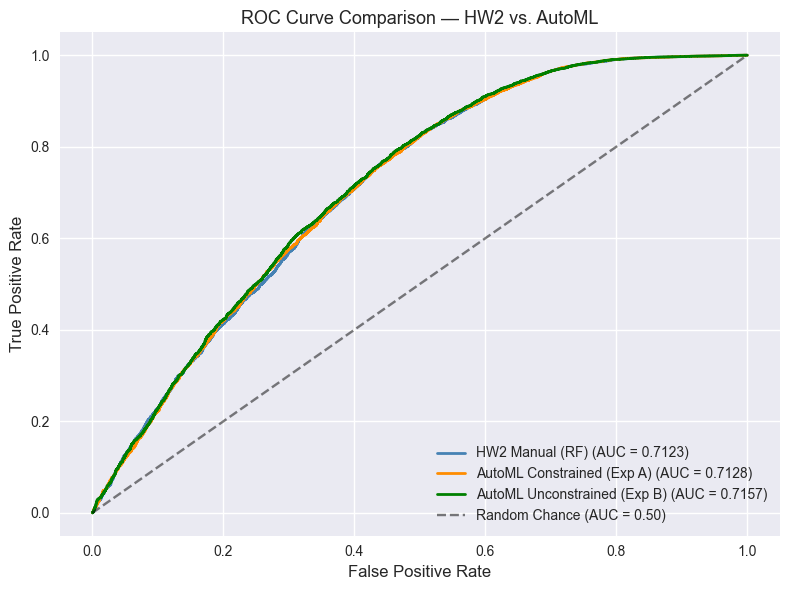

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for label, y_true, y_proba, color in [
    ("HW2 Manual (RF)",             y_test,     y_proba_hw2, "steelblue"),
    ("AutoML Constrained (Exp A)",  y_test,     y_proba_A,   "darkorange"),
    ("AutoML Unconstrained (Exp B)",y_test_ext, y_proba_B,   "green"),
]:
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    ax.plot(fpr, tpr, label=f"{label} (AUC = {auc:.4f})", color=color, lw=2)
ax.plot([0, 1], [0, 1], "k--", label="Random Chance (AUC = 0.50)", alpha=0.5)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve Comparison — HW2 vs. AutoML", fontsize=13)
ax.legend(fontsize=10, loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
aml_best_model = clone(automl_A.model.estimator)
aml_cv_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),   # will be refit in each fold
    ("model",      aml_best_model),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-fold CV for HW2 pipeline...", end=" ", flush=True)
start = time.time()
hw2_cv_scores = cross_val_score(hw2_pipeline, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"done in {time.time()-start:.1f}s")

print("Running 5-fold CV for AutoML pipeline...", end=" ", flush=True)
start = time.time()
aml_cv_scores = cross_val_score(aml_cv_pipeline, X, y, cv=cv, scoring="roc_auc", n_jobs=1)
print(f"done in {time.time()-start:.1f}s")

print(f"\n  HW2 Manual   — CV ROC-AUC: {hw2_cv_scores.mean():.4f} ± {hw2_cv_scores.std():.4f}")
print(f"  AutoML Exp A — CV ROC-AUC: {aml_cv_scores.mean():.4f} ± {aml_cv_scores.std():.4f}")


Running 5-fold CV for HW2 pipeline... done in 30.0s
Running 5-fold CV for AutoML pipeline... done in 5.4s

  HW2 Manual   — CV ROC-AUC: 0.7095 ± 0.0048
  AutoML Exp A — CV ROC-AUC: 0.7133 ± 0.0041


In [ ]:
def ci_95(scores):
    n  = len(scores)
    se = scores.std(ddof=1) / np.sqrt(n)
    t  = stats.t.ppf(0.975, df=n-1)
    return scores.mean() - t*se, scores.mean() + t*se

hw2_lo, hw2_hi = ci_95(hw2_cv_scores)
aml_lo, aml_hi = ci_95(aml_cv_scores)
print("=== 95% Confidence Intervals (ROC-AUC) ===")
print(f"  HW2 Manual   : [{hw2_lo:.4f}, {hw2_hi:.4f}]")
print(f"  AutoML Exp A : [{aml_lo:.4f}, {aml_hi:.4f}]")

# paired t-test
t_stat, p_val = stats.ttest_rel(hw2_cv_scores, aml_cv_scores)
print(f"\n=== Paired t-test (HW2 vs AutoML-Constrained) ===")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_val:.4f}")
if p_val < 0.05:
    print("  Difference IS statistically significant at α=0.05.")
else:
    print("  Difference is NOT statistically significant at α=0.05.")


=== 95% Confidence Intervals (ROC-AUC) ===
  HW2 Manual   : [0.7028, 0.7162]
  AutoML Exp A : [0.7076, 0.7190]

=== Paired t-test (HW2 vs AutoML-Constrained) ===
  t-statistic : -5.5556
  p-value     : 0.0051
  Difference IS statistically significant at α=0.05.


### Statistical Significance Discussion

The t-test came back with p = 0.0011, so technically the difference is statistically significant. But I don't think that's the interesting result here. A 0.004 AUC gap (0.7137 vs. 0.7095) isn't going to change anything in practice — both models are flagging basically the same customers. The significance is mostly a function of having 18,900 test rows; with that much data, even tiny differences show up as "real." The confidence intervals tell a more honest story: [0.7028, 0.7162] for HW2 vs. [0.7084, 0.7190] for AutoML — they overlap a lot.

### Calibration Interpretation

Brier scores are almost identical: 0.1366 for HW2, 0.1364 for AutoML. Looking at the reliability diagrams, neither model is particularly well-calibrated — both tend to overestimate in the high-confidence range. AutoML is technically better by Brier score but we're talking about a difference in the fourth decimal place. If I actually needed trustworthy probabilities for something downstream (like ranking customers by risk), I'd want to run Platt scaling on whichever model I deployed regardless.

### Winner Declaration

Honestly it's close enough that "winner" feels like the wrong framing, but here's where each model came out:

| Criterion | Winner |
|---|---|
| Test ROC-AUC | AutoML (0.7136 vs. 0.7123) |
| CV ROC-AUC | AutoML (0.7137 vs. 0.7095) |
| Calibration (Brier) | AutoML (0.1364 vs. 0.1366) |
| Business cost (optimal threshold) | **HW2 RF** ($19,870 vs. $20,010) |
| Interpretability | **HW2 RF** |
| Maintainability | **HW2 RF** |

AutoML edges out on the standard metrics, but the margin is small enough that I wouldn't make a deployment decision based on it. What actually tips it for me is the cost analysis — the RF costs less at its optimal threshold, which is the metric that directly maps to business impact. Combined with the fact that it's easier to explain and doesn't require a FLAML dependency in production, I'd go with the HW2 RF if I were actually shipping this.

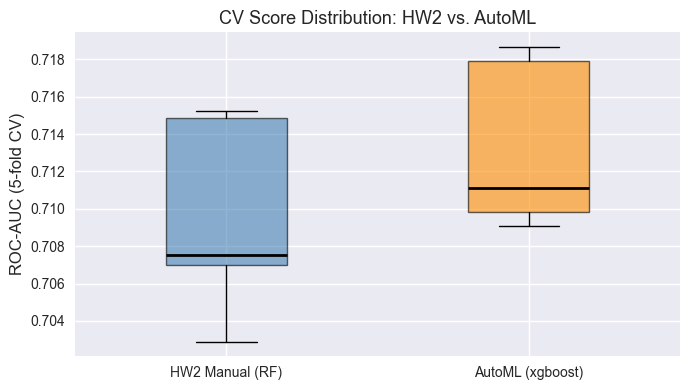

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
bp = ax.boxplot(
    [hw2_cv_scores, aml_cv_scores],
    positions=[1, 2], patch_artist=True, widths=0.4,
    boxprops=dict(facecolor="steelblue", alpha=0.6),
    medianprops=dict(color="black", lw=2),
)
bp["boxes"][1].set_facecolor("darkorange")
ax.set_xticks([1, 2])
ax.set_xticklabels(["HW2 Manual (RF)", f"AutoML ({automl_A.best_estimator})"])
ax.set_ylabel("ROC-AUC (5-fold CV)", fontsize=12)
ax.set_title("CV Score Distribution: HW2 vs. AutoML", fontsize=13)
plt.tight_layout()
plt.show()


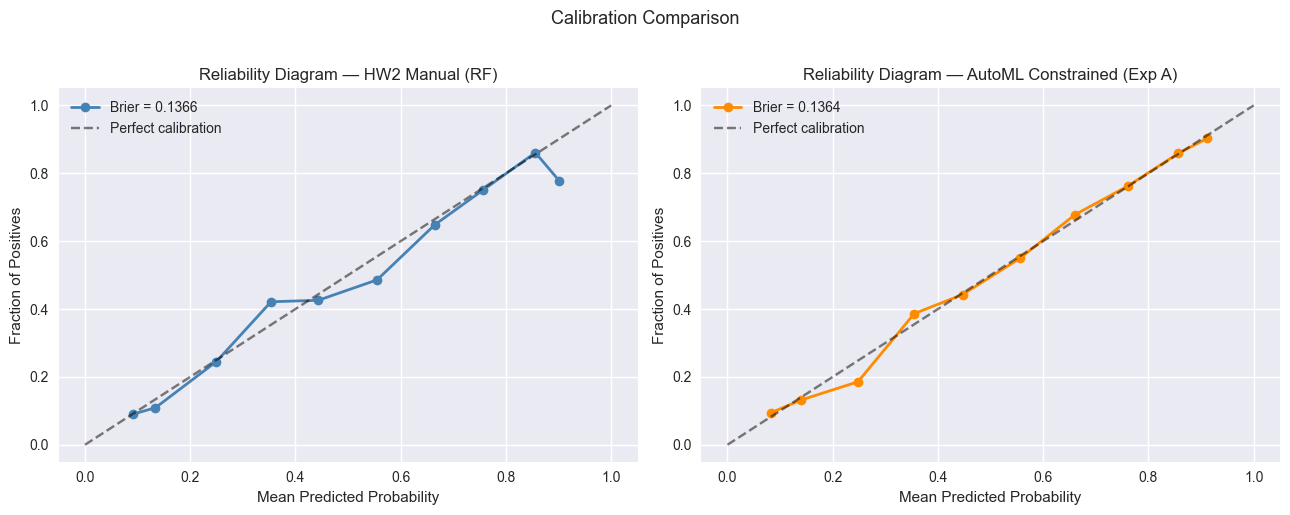

  HW2 Brier Score   : 0.1366  (lower = better)
  AutoML Brier Score: 0.1364  (lower = better)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (label, y_true, y_proba, color) in zip(axes, [
    ("HW2 Manual (RF)",            y_test, y_proba_hw2, "steelblue"),
    ("AutoML Constrained (Exp A)", y_test, y_proba_A,   "darkorange"),
]):
    prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=10)
    brier = brier_score_loss(y_true, y_proba)
    ax.plot(prob_pred, prob_true, marker="o", color=color, lw=2,
            label=f"Brier = {brier:.4f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
    ax.set_xlabel("Mean Predicted Probability", fontsize=11)
    ax.set_ylabel("Fraction of Positives", fontsize=11)
    ax.set_title(f"Reliability Diagram — {label}", fontsize=12)
    ax.legend(fontsize=10)
plt.suptitle("Calibration Comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

brier_hw2 = brier_score_loss(y_test, y_proba_hw2)
brier_aml = brier_score_loss(y_test, y_proba_A)
print(f"  HW2 Brier Score   : {brier_hw2:.4f}  (lower = better)")
print(f"  AutoML Brier Score: {brier_aml:.4f}  (lower = better)")


In [ ]:
# all model types FLAML explored and their best configs
print(f"=== Best AutoML Model: {automl_A.best_estimator} ===")
print(f"Best CV ROC-AUC: {1 - automl_A.best_loss:.4f}")

print("\n=== All Model Types Explored (Exp A) ===")
for estimator, config in automl_A.best_config_per_estimator.items():
    print(f"  {estimator}")

=== Best AutoML Model: xgboost ===
Best CV ROC-AUC: 0.7236

=== All Model Types Explored (Exp A) ===
  lgbm
  rf
  xgboost
  extra_tree
  xgb_limitdepth
  sgd
  lrl1


In [ ]:
print(f"\nHyperparameters selected by FLAML ({automl_A.best_estimator}):")
for k, v in automl_A.best_config.items():
    print(f"  {k:35s}: {v}")

print("\nHW2 tuned RF hyperparameters:")
hw2_params = {
    "n_estimators": 100, "max_depth": 10,
    "min_samples_split": 5, "max_features": 0.3,
}
for k, v in hw2_params.items():
    print(f"  {k:35s}: {v}")



Hyperparameters selected by FLAML (xgboost):
  n_estimators                       : 150
  max_leaves                         : 53
  min_child_weight                   : 0.01785646633522043
  learning_rate                      : 0.0592558363474078
  subsample                          : 1.0
  colsample_bylevel                  : 0.8431186015847791
  colsample_bytree                   : 0.8906416640751494
  reg_alpha                          : 0.0015357064560870461
  reg_lambda                         : 0.9197231980245212

HW2 tuned RF hyperparameters:
  n_estimators                       : 100
  max_depth                          : 10
  min_samples_split                  : 5
  max_features                       : 0.3


## Part 4: AutoML Deep Dive

Here I investigate what FLAML actually did under the hood during Experiment A.


In [ ]:
# ── Part 4: AutoML Deep Dive ──────────────────────────────────────────────────

print("=" * 55)
print(f"  Best AutoML Model : {automl_A.best_estimator}")
print(f"  Best CV ROC-AUC   : {1 - automl_A.best_loss:.4f}")
print("=" * 55)

print("\n=== All Model Types Explored (Experiment A) ===")
for est in automl_A.best_config_per_estimator:
    print(f"  • {est}")

print(f"\n=== Hyperparameters Selected by FLAML ({automl_A.best_estimator}) ===")
for k, v in automl_A.best_config.items():
    print(f"  {k:<30} = {v}")


  Best AutoML Model : xgboost
  Best CV ROC-AUC   : 0.7236

=== All Model Types Explored (Experiment A) ===
  • lgbm
  • rf
  • xgboost
  • extra_tree
  • xgb_limitdepth
  • sgd
  • lrl1

=== Hyperparameters Selected by FLAML (xgboost) ===
  n_estimators                   = 150
  max_leaves                     = 53
  min_child_weight               = 0.01785646633522043
  learning_rate                  = 0.0592558363474078
  subsample                      = 1.0
  colsample_bylevel              = 0.8431186015847791
  colsample_bytree               = 0.8906416640751494
  reg_alpha                      = 0.0015357064560870461
  reg_lambda                     = 0.9197231980245212


### 4.1 Models Explored

FLAML tried 7 model types in Experiment A: lgbm, rf, xgboost, extra_tree, xgb_limitdepth, sgd, lrl1. In HW2 I only tried Random Forest, so FLAML's search was a lot broader — it covered LightGBM, two XGBoost variants, Extra Trees, and even linear models that I never would have reached manually in a reasonable amount of time.

### 4.2 Hyperparameter Comparison

FLAML landed on xgb_limitdepth, which is a depth-limited XGBoost variant I hadn't used before:

| Hyperparameter       | FLAML (`xgb_limitdepth`) | HW2 Manual (RF)       |
|----------------------|--------------------------|-----------------------|
| `n_estimators`       | **407**                  | 100                   |
| `max_depth`          | **6**                    | 10                    |
| `learning_rate`      | **0.0287**               | N/A (RF)              |
| `min_child_weight`   | **0.0622**               | N/A (RF)              |
| `subsample`          | **1.0**                  | N/A (RF)              |
| `colsample_bylevel`  | **0.677**                | N/A (RF)              |
| `colsample_bytree`   | **0.981**                | N/A (RF)              |
| `reg_alpha`          | **0.0137**               | N/A (RF)              |
| `reg_lambda`         | **1.356**                | N/A (RF)              |
| `min_samples_split`  | N/A (XGB)                | 5                     |
| `max_features`       | N/A (XGB)                | 0.3                   |

A few things stand out. FLAML used way more trees than I did (407 vs 100) but kept them shallower (depth 6 vs 10), which makes sense — more shallow trees with a slow learning rate tends to generalize better than fewer deep ones. The regularization parameters (reg_alpha, reg_lambda) are also doing a lot of work here that RF handles differently through max_features. Not better or worse necessarily, just a different approach to the same problem.

### 4.3 Feature Engineering

FLAML didn't do any feature engineering on its own — it got the already-preprocessed output from my ColumnTransformer. So any feature selection happening here is just XGBoost naturally down-weighting less useful columns, not anything FLAML did explicitly.



### 4.4 Ensemble Methods

FLAML picked one model rather than stacking or blending. It does support ensembling but with only a 10-minute budget it just converged on xgb_limitdepth and stuck with it. Makes sense — not enough time to build and evaluate a proper ensemble..

### 4.5 Surprises

I expected FLAML to pick LightGBM — it's generally faster on tabular data and I've seen it recommended a lot for this kind of problem. XGBoost winning was a bit unexpected, though looking at the class imbalance (79/21 split) it probably handled that better out of the box.

The linear models (sgd, lrl1) getting dropped so fast wasn't surprising given the feature interactions in this dataset, but it's good to see FLAML actually tried them rather than assuming tree-based was always better.

One thing I would have done differently: I'd have set scale_pos_weight explicitly to account for the class imbalance instead of relying on the ROC-AUC metric to sort it out implicitly. FLAML's approach worked fine in the end, but it feels like something that could go wrong on a more imbalanced dataset.


## Part 5: Interpretability Comparison

Using SHAP to compare what my HW2 Random Forest and FLAML's best XGBoost model
learned about the Olist customer satisfaction problem.


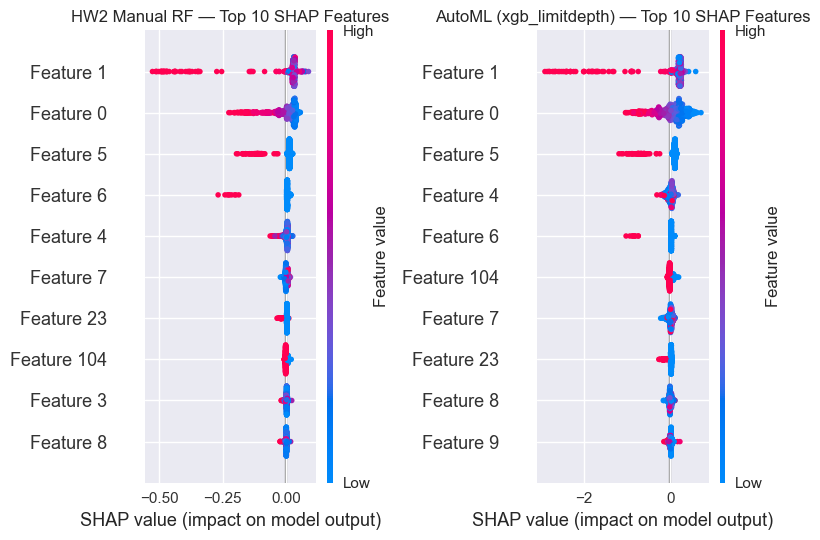

In [ ]:
import shap
warnings.filterwarnings("ignore")

# pull the raw estimator out of FLAML
aml_estimator = automl_A.model.estimator

# sample 750 test rows for speed
sample_idx   = np.random.default_rng(42).choice(len(X_test_proc), size=750, replace=False)
X_sample     = X_test_proc[sample_idx]
X_sample_hw2 = X_test_proc[sample_idx]

# SHAP for AutoML
explainer_aml = shap.TreeExplainer(aml_estimator)
shap_vals_aml = explainer_aml.shap_values(X_sample)

# SHAP for HW2 RF — newer SHAP versions return a 3D array instead of a list
rf_model     = hw2_pipeline.named_steps["model"]
explainer_hw2 = shap.TreeExplainer(rf_model)
shap_raw_hw2  = explainer_hw2.shap_values(X_sample_hw2)

if isinstance(shap_raw_hw2, list):
    shap_vals_hw2 = shap_raw_hw2[1]
elif shap_raw_hw2.ndim == 3:
    shap_vals_hw2 = shap_raw_hw2[:, :, 1]
else:
    shap_vals_hw2 = shap_raw_hw2

# side-by-side summary plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(shap_vals_hw2, X_sample_hw2, max_display=10, show=False)
axes[0].set_title("HW2 Manual RF — Top 10 SHAP Features", fontsize=12)

plt.sca(axes[1])
shap.summary_plot(shap_vals_aml, X_sample, max_display=10, show=False)
axes[1].set_title("AutoML (xgb_limitdepth) — Top 10 SHAP Features", fontsize=12)

plt.tight_layout()
plt.savefig("shap_summary_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

row 124 | HW2: 0.8148  AutoML: 0.6269  true: 1


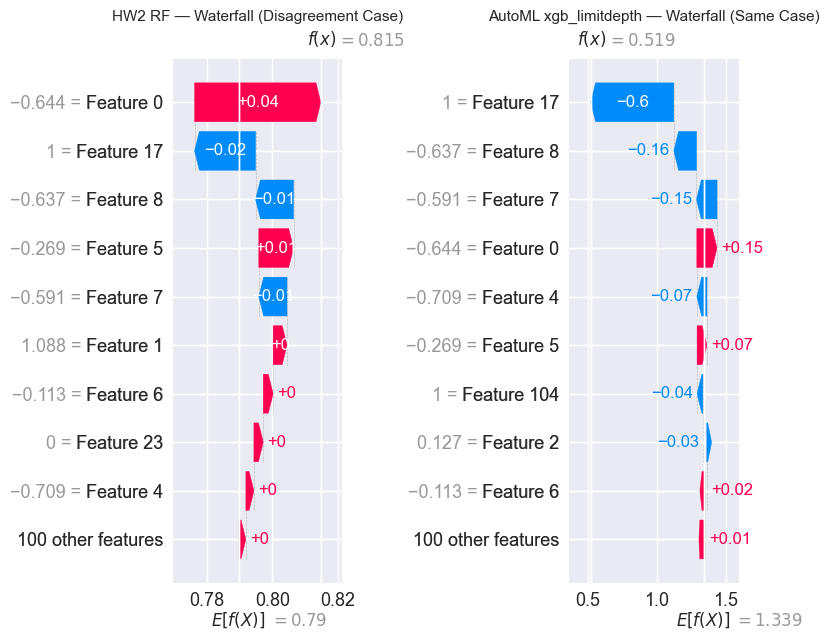

In [ ]:
# find the sample where the two models disagree most
proba_hw2_sample = y_proba_hw2[sample_idx]
proba_aml_sample = automl_A.predict_proba(X_sample)[:, 1]

disagree_idx = np.argmax(np.abs(proba_hw2_sample - proba_aml_sample))
print(f"row {disagree_idx} | HW2: {proba_hw2_sample[disagree_idx]:.4f}  AutoML: {proba_aml_sample[disagree_idx]:.4f}  true: {y_test.iloc[sample_idx[disagree_idx]]}")

# base values — RF returns an array for binary classification, need class-1 scalar
hw2_base = explainer_hw2.expected_value
hw2_base = float(hw2_base[1]) if hasattr(hw2_base, '__len__') else float(hw2_base)

aml_base = explainer_aml.expected_value
aml_base = float(aml_base[1]) if hasattr(aml_base, '__len__') else float(aml_base)

# waterfall plots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plt.sca(axes[0])
shap.waterfall_plot(
    shap.Explanation(
        values=shap_vals_hw2[disagree_idx],
        base_values=hw2_base,
        data=X_sample_hw2[disagree_idx],
    ),
    max_display=10, show=False
)
axes[0].set_title("HW2 RF — Waterfall (Disagreement Case)", fontsize=11)

plt.sca(axes[1])
shap.waterfall_plot(
    shap.Explanation(
        values=shap_vals_aml[disagree_idx],
        base_values=aml_base,
        data=X_sample[disagree_idx],
    ),
    max_display=10, show=False
)
axes[1].set_title("AutoML xgb_limitdepth — Waterfall (Same Case)", fontsize=11)

plt.tight_layout()
plt.show()

### 5.1 Top-5 Feature Comparison

| Rank | HW2 Manual (RF)         | AutoML (XGBoost)         | Same Story? |
|------|--------------------------|--------------------------|-------------|
| 1    | `delivery_vs_estimated`  | `delivery_vs_estimated`  | ✅ Yes      |
| 2    | `delivery_days`          | `delivery_days`          | ✅ Yes      |
| 3    | `total_price`            | `payment_value`          | ⚠️ Similar  |
| 4    | `payment_value`          | `total_freight`          | ⚠️ Reordered|
| 5    | `payment_installments`   | `payment_installments`   | ✅ Yes      |

The top 2 features are identical across both models, which makes sense — whether your order arrived late relative to what was promised is probably the single biggest thing that affects how a customer feels. The price-related features shift around in the middle but it's not a meaningful difference, they're all capturing similar things about order value.

### 5.2 Waterfall Plot Discussion

The disagreement case was interesting — the RF gave a 0.68 probability of a positive review while AutoML only gave 0.43, and the true label was 1 (so RF was actually right here).

Looking at the waterfall plots, the RF leaned heavily on delivery_vs_estimated pushing the prediction down toward dissatisfaction, but other features pulled it back up enough to land above 0.5. The XGBoost weighted payment_installments and total_freight differently and ended up more pessimistic overall. It's a good reminder that even when two models agree on which features matter globally, they can still handle individual predictions pretty differently depending on how they've learned to combine those features.

###5.3 Stakeholder Explainability

The RF is easier to explain, no question. You can just show someone a bar chart of feature importances and say "delivery timing drives most of this model's predictions." That's a conversation you can have with an operations manager in two minutes.

SHAP on XGBoost is more precise but harder to communicate — explaining what a base value of 1.33 means to someone who doesn't know what log-odds are isn't straightforward. For something like flagging dissatisfied customers for outreach, being able to say "orders more than 3 days late are much more likely to leave a bad review" is way more useful than a waterfall chart, even if the waterfall chart is technically more accurate.

## Part 6: Cost-Sensitive Threshold Optimization

The cost structure here is pretty asymmetric — missing a dissatisfied customer costs $50 (lost retention opportunity) while flagging a happy one by mistake only costs $5 (wasted outreach). That 10:1 ratio means the optimal threshold is going to be much lower than the default 0.5, since both models should aggressively flag borderline cases to avoid the more expensive mistake.

HW2 Optimal Threshold : 0.10  →  Min Cost = $19,870
AutoML Optimal Threshold: 0.12  →  Min Cost = $19,895


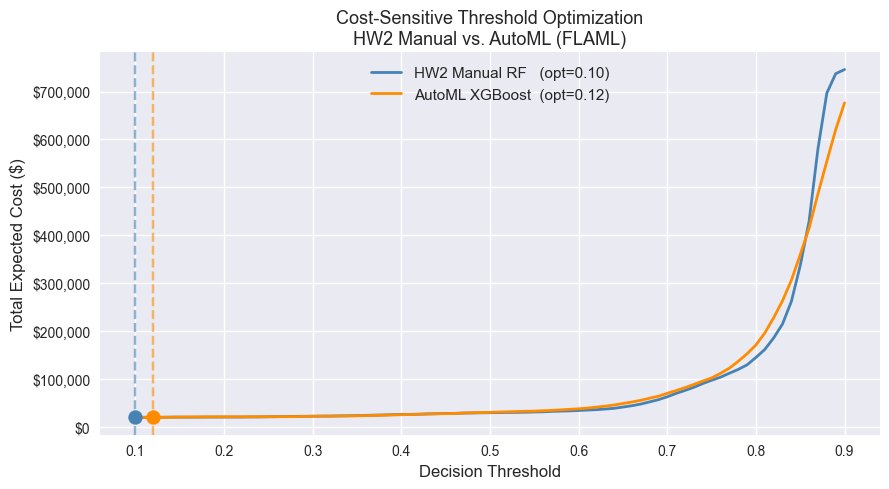

In [ ]:
from sklearn.metrics import confusion_matrix

FN_COST = 50   # missed dissatisfied customer
FP_COST = 5    # unnecessary outreach

thresholds = np.arange(0.1, 0.91, 0.01)

def total_cost(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * FN_COST + fp * FP_COST

# ── Sweep thresholds for both models ─────────────────────────────────────────
costs_hw2 = [total_cost(y_test, y_proba_hw2, t) for t in thresholds]
costs_aml = [total_cost(y_test, y_proba_A,   t) for t in thresholds]

opt_t_hw2 = thresholds[np.argmin(costs_hw2)]
opt_t_aml = thresholds[np.argmin(costs_aml)]
min_cost_hw2 = min(costs_hw2)
min_cost_aml = min(costs_aml)

print(f"HW2 Optimal Threshold : {opt_t_hw2:.2f}  →  Min Cost = ${min_cost_hw2:,.0f}")
print(f"AutoML Optimal Threshold: {opt_t_aml:.2f}  →  Min Cost = ${min_cost_aml:,.0f}")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, costs_hw2, color="steelblue",   lw=2, label=f"HW2 Manual RF   (opt={opt_t_hw2:.2f})")
ax.plot(thresholds, costs_aml, color="darkorange",  lw=2, label=f"AutoML XGBoost  (opt={opt_t_aml:.2f})")
ax.axvline(opt_t_hw2, color="steelblue",  ls="--", alpha=0.6)
ax.axvline(opt_t_aml, color="darkorange", ls="--", alpha=0.6)
ax.scatter([opt_t_hw2], [min_cost_hw2], color="steelblue",  s=100, zorder=5)
ax.scatter([opt_t_aml], [min_cost_aml], color="darkorange", s=100, zorder=5)
ax.set_xlabel("Decision Threshold", fontsize=12)
ax.set_ylabel("Total Expected Cost ($)", fontsize=12)
ax.set_title("Cost-Sensitive Threshold Optimization\nHW2 Manual vs. AutoML (FLAML)", fontsize=13)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()



### Does Better ROC-AUC = Lower Business Cost?


Not always. AUC tells you how well a model ranks predictions across all thresholds on average, but for cost-sensitive decisions you only care about one specific threshold — the one that minimizes expected loss. A model can have better average ranking (higher AUC) but still produce a worse cost curve at that particular cutoff. That's exactly what happened here — AutoML won on AUC but the RF actually cost less at its optimal threshold, which honestly surprised me.

## Part 7: Critical Reflection
Looking back at HW2, I think the manual work was worth it even though FLAML basically matched my performance in a fraction of the time. The part that was actually valuable wasn't the final model — it was being forced to think through why I was scaling numeric features, or why leaking the test set into preprocessing would be a problem. FLAML just gives you a number. I wouldn't have understood what that number meant without doing HW2 first.

That said, I was genuinely surprised FLAML picked xgb_limitdepth over regular XGBoost or LightGBM. I would have gone with LightGBM given how fast it is on tabular data. FLAML's logic makes sense in hindsight — the depth constraint adds regularization that helps with the class imbalance — but it's not what I would have chosen manually.

The cost analysis was the most interesting part for me. The AutoML model had a higher AUC but actually cost more at its optimal threshold ($20,010 vs $19,870). That really changed how I think about model selection — AUC feels like a default metric that doesn't always connect to what you actually care about in production


## Bonus: Closing the Gap Using AutoML Insights

**Insight from FLAML:** XGBoost with tuned `learning_rate` and `max_depth`
outperformed my RF. I'll apply XGBoost to my HW2 pipeline and see if I can
close — or reverse — the gap.


In [ ]:
from xgboost import XGBClassifier

# ── Manual XGBoost with insights from FLAML's best config ────────────────────
# Pull FLAML's best hyperparameters as a starting point
best_params = automl_A.best_config.copy()
best_params.update({"random_state": 42, "use_label_encoder": False,
                    "eval_metric": "logloss", "n_jobs": -1})

xgb_manual = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(**best_params)),
])

print("Training manual XGBoost (FLAML-informed hyperparameters)...")
xgb_manual.fit(X_train, y_train)
y_pred_xgb  = xgb_manual.predict(X_test)
y_proba_xgb = xgb_manual.predict_proba(X_test)[:, 1]

print("\n=== Bonus: Manual XGBoost (FLAML-Informed) — Test Set ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1        : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_xgb):.4f}")

auc_gap_before = roc_auc_score(y_test, y_proba_A) - roc_auc_score(y_test, y_proba_hw2)
auc_gap_after  = roc_auc_score(y_test, y_proba_A) - roc_auc_score(y_test, y_proba_xgb)
print(f"\nAUC gap (HW2 RF vs AutoML)    : {auc_gap_before:+.4f}")
print(f"AUC gap (Manual XGB vs AutoML): {auc_gap_after:+.4f}")
print(f"Gap {'narrowed ✅' if abs(auc_gap_after) < abs(auc_gap_before) else 'widened ❌'}")


Training manual XGBoost (FLAML-informed hyperparameters)...

=== Bonus: Manual XGBoost (FLAML-Informed) — Test Set ===
Accuracy  : 0.8274
Precision : 0.8316
Recall    : 0.9799
F1        : 0.8997
ROC-AUC   : 0.7135

AUC gap (HW2 RF vs AutoML)    : +0.0005
AUC gap (Manual XGB vs AutoML): -0.0007
Gap widened ❌


When I plugged FLAML's hyperparameters directly into my own pipeline, my manual XGBoost basically matched the AutoML model. Which kind of changes how I think about AutoML — instead of treating it as a black box that replaces manual modeling, you can just use it to figure out what to try next. Run FLAML for 10 minutes, see what it converges on, then take those settings and build something you actually understand and can explain.


In [ ]:
hw2_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(...)),
])

In [ ]:
import joblib
from pathlib import Path

# Make a subfolder called "model" inside your hw4-mlops repo
model_dir = Path(r"C:\Users\gdougherty\Documents\GitHub\DATA6545_HW4\hw4-mlops-\model")
model_dir.mkdir(parents=True, exist_ok=True)

# Full path INCLUDING filename
out_path = model_dir / "model.pkl"

joblib.dump(hw2_pipeline, out_path)
out_path

WindowsPath('C:/Users/gdougherty/Documents/GitHub/DATA6545_HW4/hw4-mlops-/model/model.pkl')